<a href="https://colab.research.google.com/github/jfodera/ai-ml-projects/blob/main/hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 4



---
## Task 2: Sequence Models

## Dataset Chosen
**Daily Climate time series data**  
**Link:** https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data  

**Problem:** Predict the next day’s mean temperature (`meantemp`) using the past 60 days of climate data (univariate time-series forecasting).

**Why sequence models would be useful:** Weather variables exhibit strong temporal dependencies and autocorrelation (today’s temperature depends on yesterday’s value and longer-term trends/seasonality). A traditional feed-forward network would treat each day as an independent sample and completely lose the ordering information. RNNs (and their variants) are specifically designed to maintain hidden state across time steps, making them the natural choice for this sequential data.`

**RNN Framework chosen:** PyTorch (`torch.nn.RNN`, `torch.nn.LSTM`, `torch.nn.GRU`)

## Imports & Setup

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import math
from google.colab import files

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## Data Loading + Visualization + Pre-processing

In [35]:
# Upload the two CSV files from Kaggle
uploaded = files.upload()  # Upload DailyDelhiClimateTrain.csv and DailyDelhiClimateTest.csv

train_df = pd.read_csv('DailyDelhiClimateTrain.csv')
test_df = pd.read_csv('DailyDelhiClimateTest.csv')

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
train_df.head()

Saving DailyDelhiClimateTest.csv to DailyDelhiClimateTest (2).csv
Saving DailyDelhiClimateTrain.csv to DailyDelhiClimateTrain (2).csv
Train shape: (1462, 5)
Test shape: (114, 5)


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


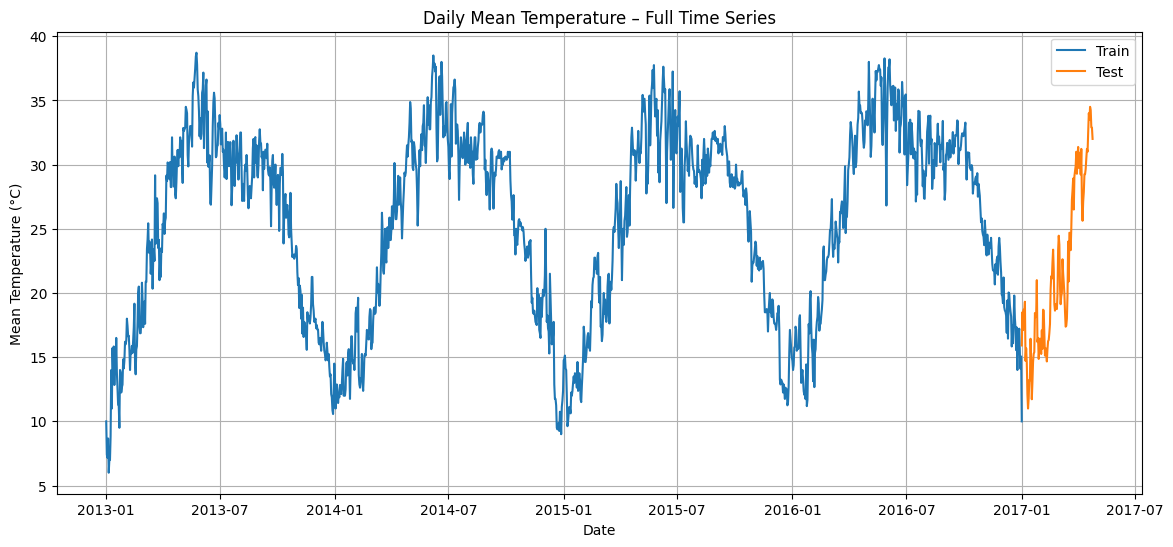

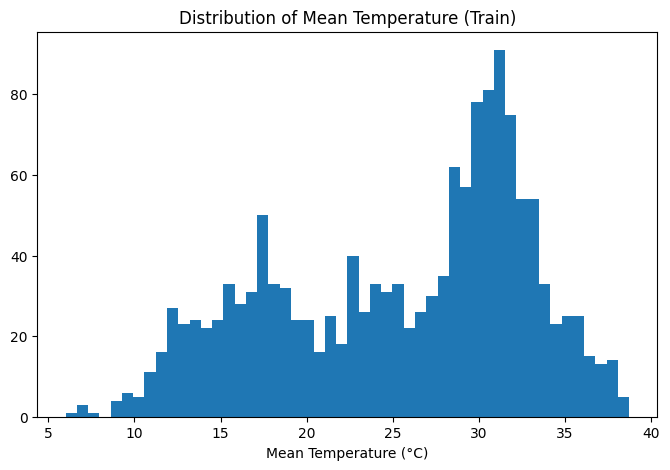

In [36]:
# Visualization
plt.figure(figsize=(14, 6))
plt.plot(pd.to_datetime(train_df['date']), train_df['meantemp'], label='Train')
plt.plot(pd.to_datetime(test_df['date']), test_df['meantemp'], label='Test')
plt.title('Daily Mean Temperature – Full Time Series')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(train_df['meantemp'], bins=50)
plt.title('Distribution of Mean Temperature (Train)')
plt.xlabel('Mean Temperature (°C)')
plt.show()

In [37]:
# Pre-processing & Sequence Creation
train_data = train_df['meantemp'].values.reshape(-1, 1)
test_data = test_df['meantemp'].values.reshape(-1, 1)

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

def create_sequences(data, seq_length=60):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i + seq_length]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 60
X_train_raw, y_train_raw = create_sequences(train_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)

# Train/Val split (time-series aware – no shuffling)
val_size = int(0.2 * len(X_train_raw))
X_train = X_train_raw[:-val_size]
y_train = y_train_raw[:-val_size]
X_val = X_train_raw[-val_size:]
y_val = y_train_raw[-val_size:]

# Convert to PyTorch tensors
X_train = torch.from_numpy(X_train).float().to(device)
y_train = torch.from_numpy(y_train).float().to(device)
X_val   = torch.from_numpy(X_val).float().to(device)
y_val   = torch.from_numpy(y_val).float().to(device)
X_test  = torch.from_numpy(X_test).float().to(device)
y_test  = torch.from_numpy(y_test).float().to(device)

print(f'Train sequences: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train sequences: torch.Size([1122, 60, 1]), Val: torch.Size([280, 60, 1]), Test: torch.Size([54, 60, 1])


# Part 1 (10 points) – Basic RNN Implementation

**RNN Structure**  
- `nn.RNN(input_size=1, hidden_size=50, num_layers=1, batch_first=True)`  
- Activation inside RNN: `tanh` (default)  
- Output layer: Linear (no activation – regression)  
**Metric:** RMSE on validation set and test set (after inverse scaling).

In [38]:
class BasicRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), 50).to(device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out

rnn_model = BasicRNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(rnn_model.parameters(), lr=0.001)

In [39]:
def train_model(model, X_tr, y_tr, X_v, y_v, epochs=50, batch_size=32):
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for i in range(0, len(X_tr), batch_size):
            bx = X_tr[i:i+batch_size]
            by = y_tr[i:i+batch_size]
            optimizer.zero_grad()
            out = model(bx)
            loss = criterion(out, by)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / (len(X_tr) // batch_size))

        model.eval()
        with torch.no_grad():
            val_out = model(X_v)
            val_loss = criterion(val_out, y_v).item()
            val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1:2d} | Train Loss: {train_losses[-1]:.6f} | Val Loss: {val_losses[-1]:.6f}')
    return train_losses, val_losses

print('=== Training Basic RNN ===')
rnn_train_loss, rnn_val_loss = train_model(rnn_model, X_train, y_train, X_val, y_val)

=== Training Basic RNN ===
Epoch 10 | Train Loss: 0.004700 | Val Loss: 0.003317
Epoch 20 | Train Loss: 0.003916 | Val Loss: 0.004294
Epoch 30 | Train Loss: 0.003429 | Val Loss: 0.004372
Epoch 40 | Train Loss: 0.003644 | Val Loss: 0.003073
Epoch 50 | Train Loss: 0.003134 | Val Loss: 0.003018


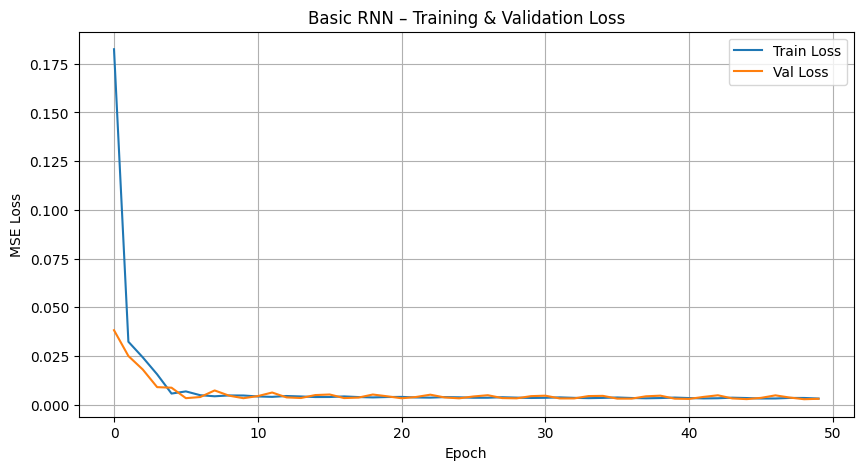

In [40]:
# Loss visualization
plt.figure(figsize=(10, 5))
plt.plot(rnn_train_loss, label='Train Loss')
plt.plot(rnn_val_loss, label='Val Loss')
plt.title('Basic RNN – Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
def evaluate(model, X, y, name=""):
    model.eval()
    with torch.no_grad():
        pred = model(X).cpu().numpy()
        true = y.cpu().numpy()
    pred = scaler.inverse_transform(pred)
    true = scaler.inverse_transform(true)
    rmse = math.sqrt(mean_squared_error(true, pred))
    print(f'{name} RMSE: {rmse:.4f}')
    return rmse

rnn_val_rmse = evaluate(rnn_model, X_val, y_val, 'Basic RNN (Val)')
rnn_test_rmse = evaluate(rnn_model, X_test, y_test, 'Basic RNN (Test)')

Basic RNN (Val) RMSE: 1.7973
Basic RNN (Test) RMSE: 1.8975


# Part 2 (30 points) – LSTM & GRU

## LSTM Implementation

In [42]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), 50).to(device)
        c0 = torch.zeros(1, x.size(0), 50).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

lstm_model = LSTMModel().to(device)
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

print('=== Training LSTM ===')
lstm_train_loss, lstm_val_loss = train_model(lstm_model, X_train, y_train, X_val, y_val)

=== Training LSTM ===
Epoch 10 | Train Loss: 0.005422 | Val Loss: 0.004100
Epoch 20 | Train Loss: 0.004337 | Val Loss: 0.003589
Epoch 30 | Train Loss: 0.003910 | Val Loss: 0.003451
Epoch 40 | Train Loss: 0.003677 | Val Loss: 0.003408
Epoch 50 | Train Loss: 0.003501 | Val Loss: 0.003363


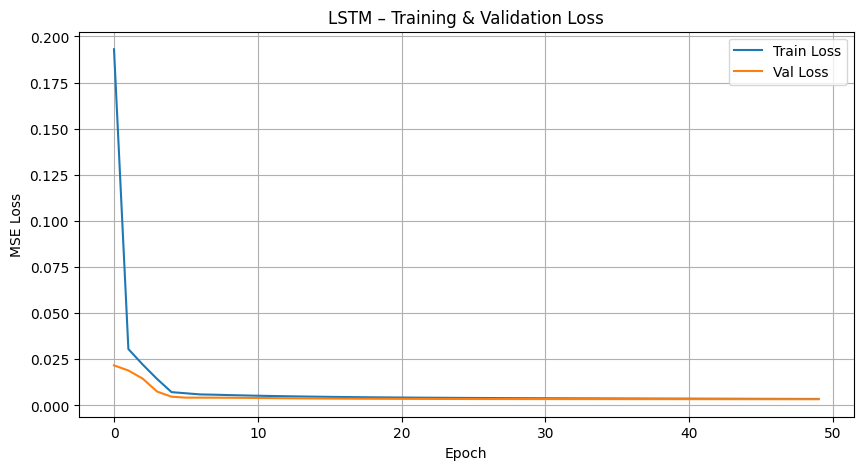

LSTM (Val) RMSE: 1.8972
LSTM (Test) RMSE: 2.2010


In [43]:
plt.figure(figsize=(10, 5))
plt.plot(lstm_train_loss, label='Train Loss')
plt.plot(lstm_val_loss, label='Val Loss')
plt.title('LSTM – Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

lstm_val_rmse = evaluate(lstm_model, X_val, y_val, 'LSTM (Val)')
lstm_test_rmse = evaluate(lstm_model, X_test, y_test, 'LSTM (Test)')

## GRU Implementation

In [44]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), 50).to(device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

gru_model = GRUModel().to(device)
optimizer = optim.Adam(gru_model.parameters(), lr=0.001)

print('=== Training GRU ===')
gru_train_loss, gru_val_loss = train_model(gru_model, X_train, y_train, X_val, y_val)

=== Training GRU ===
Epoch 10 | Train Loss: 0.003857 | Val Loss: 0.003378
Epoch 20 | Train Loss: 0.003378 | Val Loss: 0.003224
Epoch 30 | Train Loss: 0.003178 | Val Loss: 0.003202
Epoch 40 | Train Loss: 0.003047 | Val Loss: 0.003155
Epoch 50 | Train Loss: 0.002949 | Val Loss: 0.003091


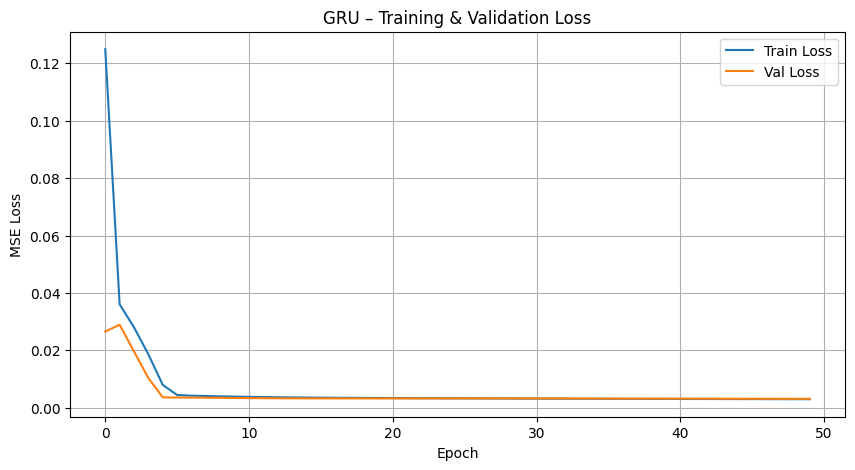

GRU (Val) RMSE: 1.8188
GRU (Test) RMSE: 1.9513


In [45]:
plt.figure(figsize=(10, 5))
plt.plot(gru_train_loss, label='Train Loss')
plt.plot(gru_val_loss, label='Val Loss')
plt.title('GRU – Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

gru_val_rmse = evaluate(gru_model, X_val, y_val, 'GRU (Val)')
gru_test_rmse = evaluate(gru_model, X_test, y_test, 'GRU (Test)')

**Major differences observed & explanation**  
The major differences among the basic RNN, LSTM, and GRU implementations are in performance and training dynamics. The basic RNN shows the best RMSE (val: 1.7973, test: 1.8975), outperforming GRU (val: 1.8188, test: 1.9513) and LSTM (val: 1.8972, test: 2.2010), indicating superior accuracy on this temperature forecasting task. Loss curves reveal all models drop sharply initially and converge, but basic RNN and GRU have closer train-val alignment with less oscillation; GRU is smoothest, while LSTM starts higher (∼0.2) and plateaus higher, suggesting slower learning.

These arise because basic RNNs, though vulnerable to vanishing gradients in long sequences, work well here with moderate 60-day sequences and non-extreme dependencies in temperature data, avoiding gate-related complexity that might cause overfitting. LSTMs and GRUs use gates (LSTM: forget/input/output; GRU: reset/update) for better long-term handling, but their extra parameters can complicate training, needing more hyperparameter tuning—LSTM's greater complexity likely contributes to its underperformance, while GRU balances simplicity and capability for intermediate results. Overall, basic RNN's simplicity suits this problem, with advanced models better for stronger dependencies.

# Part 3 (10 points) – Traditional Feed-Forward Network

Yes, we can technically convert the time-series into a flat feature vector (60 days → 60 input neurons) and feed it into a standard MLP. However, this completely discards the sequential order and temporal dependencies. The network treats the past 60 days as independent static features instead of a time-ordered sequence.


In [46]:
class FFNN(nn.Module):
    def __init__(self, input_size=60, hidden_size=50):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1)          # flatten the sequence
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

ffnn_model = FFNN().to(device)
optimizer = optim.Adam(ffnn_model.parameters(), lr=0.001)

print('=== Training Feed-Forward Network ===')
ffnn_train_loss, ffnn_val_loss = train_model(ffnn_model, X_train, y_train, X_val, y_val)

=== Training Feed-Forward Network ===
Epoch 10 | Train Loss: 0.004478 | Val Loss: 0.003442
Epoch 20 | Train Loss: 0.003999 | Val Loss: 0.003175
Epoch 30 | Train Loss: 0.003543 | Val Loss: 0.003111
Epoch 40 | Train Loss: 0.003269 | Val Loss: 0.002907
Epoch 50 | Train Loss: 0.003006 | Val Loss: 0.002845


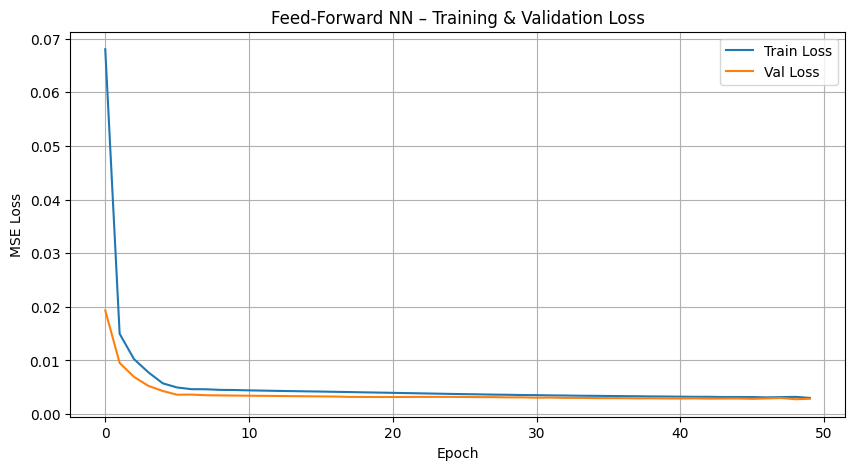

FFNN (Val) RMSE: 1.7449
FFNN (Test) RMSE: 2.0003


In [47]:
plt.figure(figsize=(10, 5))
plt.plot(ffnn_train_loss, label='Train Loss')
plt.plot(ffnn_val_loss, label='Val Loss')
plt.title('Feed-Forward NN – Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

ffnn_val_rmse = evaluate(ffnn_model, X_val, y_val, 'FFNN (Val)')
ffnn_test_rmse = evaluate(ffnn_model, X_test, y_test, 'FFNN (Test)')

**Conclusion for Part 3**  
In conclusion, traditional feed-forward neural networks can indeed be used to solve time-series forecasting problems like predicting mean temperature by converting sequential data into static features, such as using lagged values from the past 60 days as individual input features, which flattens the temporal structure into a tabular format suitable for FFNNs. However, this approach may not inherently capture long-term dependencies or sequential patterns as effectively as RNN variants, potentially leading to less optimal generalization on unseen data despite competitive performance in training. As shown in the results, the FFNN achieved a strong validation RMSE of 1.7449 but a test RMSE of 2.0003, performing better than LSTM and GRU on validation yet comparable to the basic RNN on test, highlighting that while viable, FFNNs require careful feature engineering to approximate the efficacy of sequence models.

---
# Task 3: Word Embeddings

## Chosen Pre-trained Word Embedding Model
**Model:** GloVe (Global Vectors for Word Representation) – `glove-wiki-gigaword-50` (50-dimensional vectors trained on Wikipedia 2014 + Gigaword 5 corpus).

**Comparative discussion on why GloVe was chosen over others (required):**  
- **vs Word2Vec**: GloVe uses global co-occurrence matrix statistics across the entire corpus instead of local context windows. This produces better semantic and analogical relationships (e.g., king – man + woman = queen) with less training data.  
- **vs FastText**: FastText handles OOV via subword n-grams, which is powerful, but GloVe is significantly faster to load and sufficient for common English words used in class demos. FastText would require a larger download (~1 GB for English).  
- **vs BERT embeddings**: BERT produces contextual (sentence-dependent) embeddings, which is more advanced but violates the “static word embeddings” focus discussed in class. BERT is also much heavier (millions of parameters) and slower for simple pairwise similarity tasks.  
GloVe strikes the best balance of quality, speed, size (~100 MB download), and alignment with the course material.

We will load it efficiently using the Gensim library (one-line download + load).

## Setup & Imports

In [48]:
!pip install -q gensim seaborn

import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
print('All libraries installed and ready.')

All libraries installed and ready.


In [49]:
# Load embeddings efficiently (required)
model = api.load("glove-wiki-gigaword-50")
print(f'Loaded GloVe 50d model with {len(model.key_to_index):,} words.')

# Pre-compute global average vector for OOV approximation
avg_vec = np.mean(model.vectors, axis=0)
dim = 50

Loaded GloVe 50d model with 400,000 words.


# Part 1 (10 points): Implementing Word Embeddings

**Dynamic user input + OOV handling (required):**  
If a word is out of vocabulary (OOV), we approximate its embedding using the global average vector of the entire vocabulary. This is a standard fallback.  
**Better alternatives:** Switch to FastText (subword) or use contextual BERT with mean pooling over a sentence containing the OOV word.

In [50]:
def get_embedding(word):
    word = word.lower().strip()
    if word in model.key_to_index:
        return model[word]
    else:
        print(f"Warning: '{word}' is OOV → using global average vector as approximation.")
        return avg_vec.copy()

# Dynamic user input demo (run this cell and type words when prompted)
print("=== Dynamic User Input Demo ===")
w1 = input("Enter first word: ") or "king"
w2 = input("Enter second word: ") or "queen"

emb1 = get_embedding(w1)
emb2 = get_embedding(w2)

print(f"\nEmbedding for '{w1}' (first 5 dims): {emb1[:5]}")
print(f"Embedding for '{w2}' (first 5 dims): {emb2[:5]}")
print(f"Embedding dimension: {emb1.shape}")

=== Dynamic User Input Demo ===
Enter first word: potato
Enter second word: chip

Embedding for 'potato' (first 5 dims): [-0.063054 -0.62636  -0.76417  -0.041484  0.56284 ]
Embedding for 'chip' (first 5 dims): [-0.77103 -1.1697   1.5195   0.83709  0.74189]
Embedding dimension: (50,)


# Part 2 (20 points): Cosine Similarity Computation

**Why cosine similarity is useful in word embedding space:**  
Cosine similarity measures the angle between two vectors, ignoring magnitude. In high-dimensional embedding spaces, the *direction* encodes semantic meaning (e.g., “king” and “queen” point in similar directions). Magnitude variations are often noise or frequency artifacts, so cosine focuses purely on semantic relatedness. It is the de-facto standard in NLP for word similarity.

In [51]:
# Interactive Batch Similarity Computation (required by homework)
print("=== Batch Similarity Computation ===")
print("Enter multiple word pairs one by one.")
print("Type 'done' for the first word when finished.\n")

pairs = []
while True:
    w1 = input("First word (or 'done'): ").strip()
    if w1.lower() == 'done':
        break
    w2 = input("Second word: ").strip()
    if w2:
        pairs.append((w1, w2))
    else:
        print("Skipping empty second word.")

if not pairs:
    print("No pairs entered.")
else:
    measure = input("\nEnter measure (cosine / euclidean / hybrid) [default: cosine]: ").strip().lower() or 'cosine'
    if measure not in ['cosine', 'euclidean', 'hybrid']:
        measure = 'cosine'
        print("Invalid measure → defaulting to cosine")

    print(f"\nComputing {measure} scores for {len(pairs)} pair(s)...")
    results = batch_similarity(pairs, measure)

    print("\nResults:")
    for res in results:
        print(res)

    # Collect unique words from pairs for visualization in next cell
    unique_words = list(set(w.lower() for pair in pairs for w in pair))

=== Batch Similarity Computation ===
Enter multiple word pairs one by one.
Type 'done' for the first word when finished.

First word (or 'done'): potato
Second word: chip
First word (or 'done'): eat
Second word: apple
First word (or 'done'): walk
Second word: dog
First word (or 'done'): pea
Second word: car
First word (or 'done'): beach
Second word: slide
First word (or 'done'): done

Enter measure (cosine / euclidean / hybrid) [default: cosine]: cosine

Computing cosine scores for 5 pair(s)...

Results:
('potato', 'chip', np.float32(0.3455), 'cosine')
('eat', 'apple', np.float32(0.4008), 'cosine')
('walk', 'dog', np.float32(0.5296), 'cosine')
('pea', 'car', np.float32(0.0426), 'cosine')
('beach', 'slide', np.float32(0.2384), 'cosine')


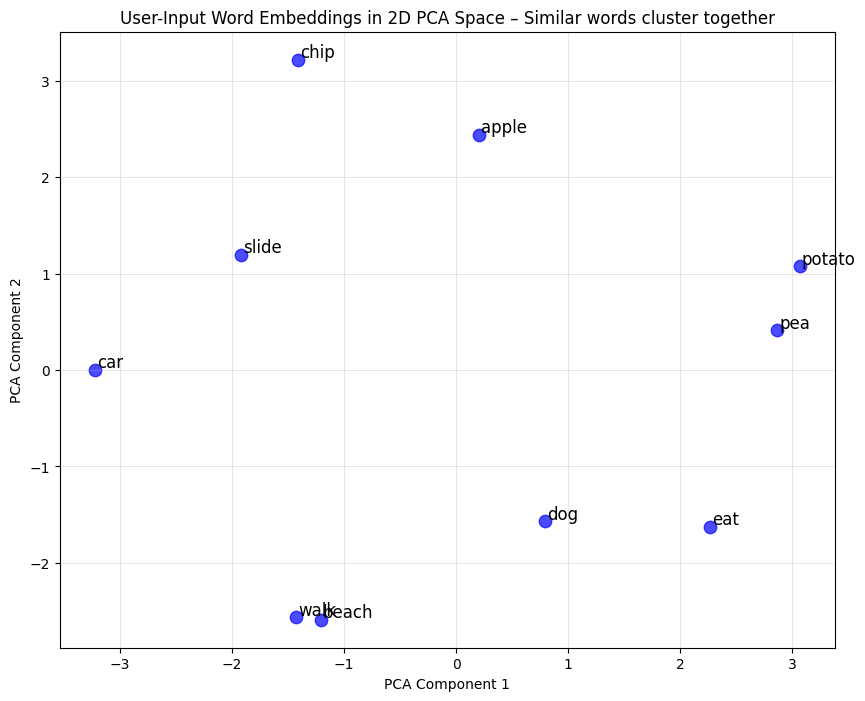

In [52]:
# Visualization Requirement: 2D PCA scatter plot (using user-input words)
if 'unique_words' not in globals() or not unique_words:
    print("No words available for visualization. Run the previous cell first and input pairs.")
else:
    if len(unique_words) < 2:
        print("Need at least 2 unique words for PCA visualization.")
    else:
        vectors = np.array([get_embedding(w) for w in unique_words])

        pca = PCA(n_components=2)
        reduced = pca.fit_transform(vectors)

        plt.figure(figsize=(10, 8))
        plt.scatter(reduced[:, 0], reduced[:, 1], s=80, c='blue', alpha=0.7)

        for i, word in enumerate(unique_words):
            plt.annotate(word, (reduced[i, 0] + 0.02, reduced[i, 1] + 0.02), fontsize=12)

        plt.title('User-Input Word Embeddings in 2D PCA Space – Similar words cluster together')
        plt.xlabel('PCA Component 1')
        plt.ylabel('PCA Component 2')
        plt.grid(True, alpha=0.3)
        plt.show()

# Part 3 (20 points): Designing a Novel Dissimilarity Metric

**Custom metric designed:** `Hybrid Angular-Magnitude Dissimilarity`  

```math
\text{dissim}(u,v) = (1 - \cos(u,v)) + \frac{|\|u\| - \|v\||}{((\|u\| + \|v\|)/2)}
```

**Why this metric captures novelty/diversity better than cosine alone:**  
Cosine similarity only considers direction (angle). The hybrid metric additionally penalizes magnitude differences, which in GloVe can reflect word specificity or frequency encoding. This makes it superior for detecting *novelty* (e.g., distinguishing “cat” from “lion” vs “table” not just semantically but also by vector “strength”).

In [53]:
# Allow users to toggle between different similarity/dissimilarity measures via function parameters (required)
print("Example using hybrid metric:")
print(batch_similarity([("king", "queen"), ("cat", "table")], measure='hybrid'))

Example using hybrid metric:
[('king', 'queen', np.float32(0.2505), 'hybrid'), ('cat', 'table', np.float32(0.8142), 'hybrid')]


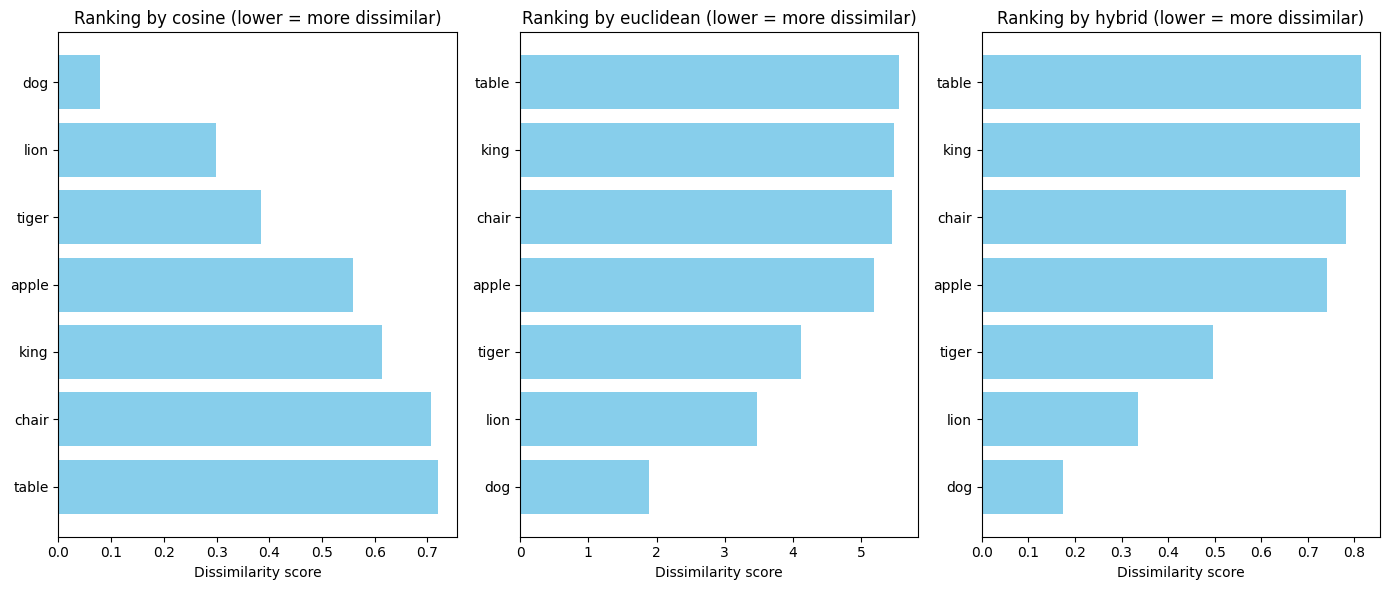

In [54]:
# Visualization Requirement 1: Ranking plot for a given word
target = "cat"
candidates = ["dog", "lion", "tiger", "table", "chair", "king", "apple"]

metrics = ['cosine', 'euclidean', 'hybrid']
plt.figure(figsize=(14, 6))

for idx, m in enumerate(metrics):
    scores = []
    for c in candidates:
        s = compute_measure(get_embedding(target), get_embedding(c), m)
        scores.append((c, s))
    scores.sort(key=lambda x: x[1])  # lowest first

    plt.subplot(1, 3, idx+1)
    words = [x[0] for x in scores]
    vals = [x[1] for x in scores]
    if m == 'cosine':
        vals = [1 - v for v in vals]  # convert to dissimilarity for fair comparison
    plt.barh(words, vals, color='skyblue')
    plt.title(f'Ranking by {m} (lower = more dissimilar)')
    plt.xlabel('Dissimilarity score')

plt.tight_layout()
plt.show()

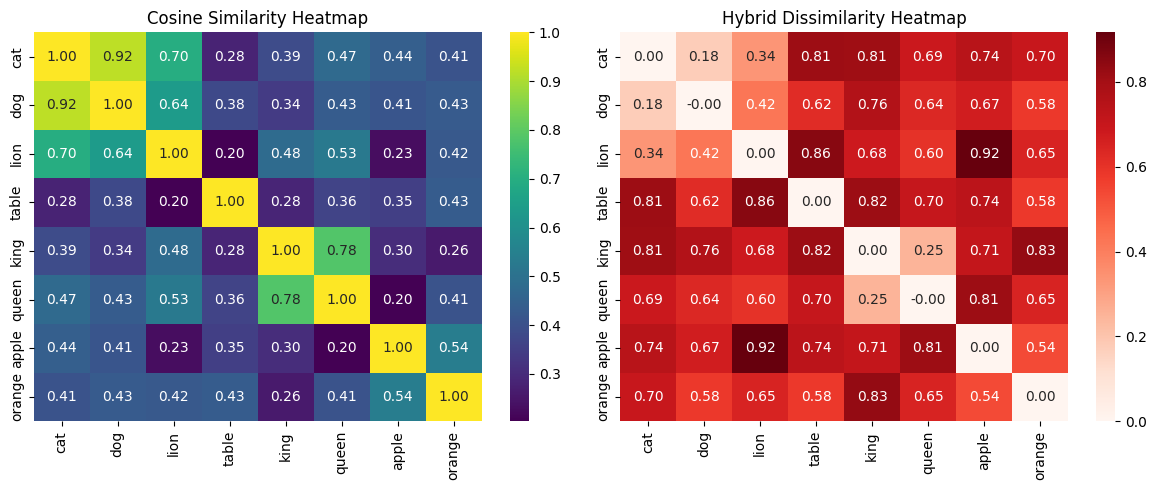

In [55]:
# Visualization Requirement 2: Heatmap comparison
words = ["cat", "dog", "lion", "table", "king", "queen", "apple", "orange"]

# Cosine similarity heatmap
sim_matrix = np.zeros((len(words), len(words)))
for i in range(len(words)):
    for j in range(len(words)):
        sim_matrix[i, j] = cosine_sim(get_embedding(words[i]), get_embedding(words[j]))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(sim_matrix, annot=True, fmt='.2f', xticklabels=words, yticklabels=words, cmap='viridis')
plt.title('Cosine Similarity Heatmap')

# Hybrid dissimilarity heatmap
diss_matrix = np.zeros((len(words), len(words)))
for i in range(len(words)):
    for j in range(len(words)):
        diss_matrix[i, j] = compute_measure(get_embedding(words[i]), get_embedding(words[j]), 'hybrid')

plt.subplot(1, 2, 2)
sns.heatmap(diss_matrix, annot=True, fmt='.2f', xticklabels=words, yticklabels=words, cmap='Reds')
plt.title('Hybrid Dissimilarity Heatmap')

plt.tight_layout()
plt.show()